# 1. Business Problem Definition
Objective : predict house sale price based on property characteristics
Problem type : Supervised Learning, Tabular data, Regression
Evaluation Metric : RMSE (Root Mean Squared Error) used to penalize large errors

# 2. Load Data & Basic Inspection
### What to Check :
Shape of dataset    : numbers of row and column
Head of dataset     : first 5 row of the dataset
Info of dataset     : obvious missing values, data types of each columns, and whether SalePrice exists only in training data

In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv('Datasets/house-prices-advanced-regression-techniques/train.csv')

In [3]:
train.shape

(1460, 81)

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# 3. Separate Features and Target
separation is mandatory to prevent leakage later

In [6]:
X = train.drop(columns = ["SalePrice"], axis = 1)
y = train["SalePrice"]

# 4. Target Variable Analysis

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='SalePrice', ylabel='Count'>

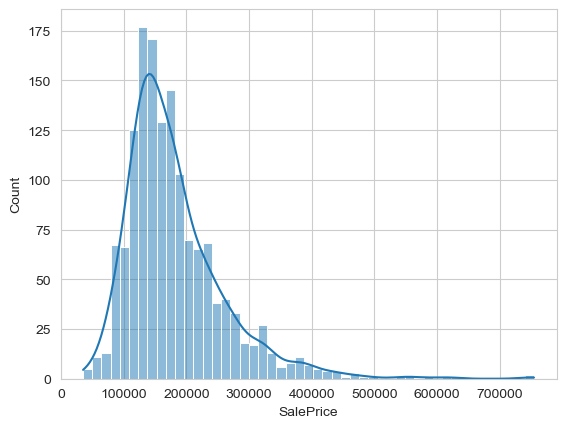

In [8]:
sns.histplot(data = y, kde = True)

#### Observation : Data distribution is Right-Skewed, long tailed of expensive houses
#### Why it matters : Linear models assume normally distributed errors, skewed targets hurts RMSE

## Applying Log Transformation

<Axes: xlabel='SalePrice', ylabel='Count'>

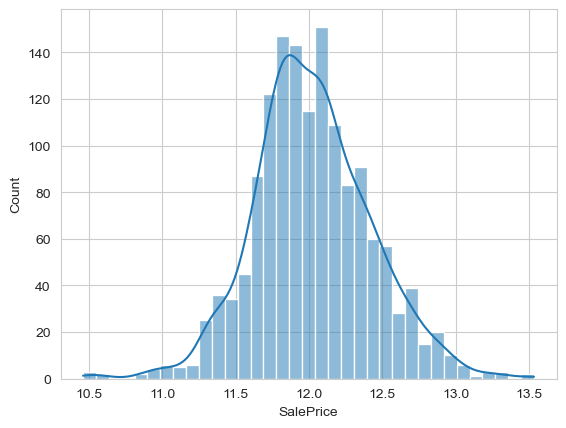

In [9]:
y_log = np.log1p(y)
sns.histplot(data = y_log, kde = True)

#### Results : Distribution is closer to normal (bell-shaped), and more stable for training
##### from now on, we model y_log, not raw price

# 5. Missing Value Analysis

In [10]:
missing = X.isna().sum().sort_values(ascending = False)
missing_percentage = (missing / len(X)) * 100
missing_percentage

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
TotalBsmtSF       0.000000
Heating           0.000000
MSSubClass        0.000000
CentralAir        0.000000
SaleCondition     0.000000
Length: 80, dtype: float64

#### Key Insight : Missing values are not random
examples : 
- PoolQC : missing means no pool for that property
- GarageType : missing means no garage
##### this determines how to impute

# 6. Split Numerical and Categorical Features
this split defines:
- Imputation strategy
- Encoding methods

In [11]:
num_features = X.select_dtypes(include = np.number).columns
cat_features = X.select_dtypes(include = "object").columns

# 7. Train-Validation Split (Before Engineering)
### Critical Rule : Any statistics (Mean, Encoding, Scaling) must be learned from training data only.

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size = 0.2, random_state = 42)

# 8. Handling Missing Values
### Numerical features - use Median value
### Categorical features - use Mode or most frequent

In [13]:
from sklearn.impute import SimpleImputer

In [14]:
# Numerical features imputer
num_imputer = SimpleImputer(strategy = "median")
X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
X_test[num_features] = num_imputer.transform(X_test[num_features])

In [15]:
# Categorical features imputer
cat_imputer = SimpleImputer(strategy= "most_frequent")
X_train[cat_features] = cat_imputer.fit_transform(X_train[cat_features])
X_test[cat_features] = cat_imputer.transform(X_test[cat_features])

# 9. Encoding Categorical Variables

In [16]:
X_train = pd.get_dummies(X_train, drop_first = True)
X_test = pd.get_dummies(X_test, drop_first = True)

X_train, X_test = X_train.align(X_test, join = "left", axis = 1, fill_value = 0)

In [17]:
X_test

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
892,893.0,20.0,70.0,8414.0,6.0,8.0,1963.0,2003.0,0.0,663.0,...,False,False,False,False,True,0,False,False,True,False
1105,1106.0,60.0,98.0,12256.0,8.0,5.0,1994.0,1995.0,362.0,1032.0,...,False,False,False,False,True,0,False,False,True,False
413,414.0,30.0,56.0,8960.0,5.0,6.0,1927.0,1950.0,0.0,0.0,...,False,False,False,False,True,0,False,False,True,False
522,523.0,50.0,50.0,5000.0,6.0,7.0,1947.0,1950.0,0.0,399.0,...,False,False,False,False,True,0,False,False,True,False
1036,1037.0,20.0,89.0,12898.0,9.0,5.0,2007.0,2008.0,70.0,1022.0,...,False,False,False,False,True,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,480.0,30.0,50.0,5925.0,4.0,7.0,1937.0,2000.0,435.0,168.0,...,False,False,False,False,True,0,True,False,False,False
1361,1362.0,20.0,124.0,16158.0,7.0,5.0,2005.0,2005.0,16.0,1274.0,...,False,False,False,False,True,0,False,False,True,False
802,803.0,60.0,63.0,8199.0,7.0,5.0,2005.0,2005.0,0.0,648.0,...,False,False,False,False,True,0,False,False,True,False
651,652.0,70.0,60.0,9084.0,4.0,5.0,1940.0,1950.0,0.0,0.0,...,False,False,False,False,True,0,False,False,True,False


### Use align() : Training and validation must have identical columns

In [18]:
print(X_train.shape)
print(X_test.shape)

(1168, 243)
(292, 243)


# 10. Feature Scaling
### Required for:
- Linear Regression
- Ridge / Lasso

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
X_train_scaled

array([[-1.11928402, -0.8667643 , -0.01246836, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.79046412,  0.07410996, -0.50235683, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.21615189, -0.63154574, -0.14607431, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [ 1.32669882, -0.8667643 , -0.45782152, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.30597137, -0.16110861, -0.6804981 , ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.93157852,  1.48542135, -0.76956873, ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(1168, 243))

# 11. Baseline Model - Linear Regression
Apply Linear Regression model, finding train and test RMSE gap

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [35]:
print("y_train range:", y_train.min(), y_train.max())
print("y_test range :", y_test.min(), y_test.max())

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_train = lr.predict(X_train_scaled)
pred_test = lr.predict(X_test_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print("Train RMSE : ", rmse_train)
print("Test RMSE : ", rmse_test)

y_train range: 10.460270761075149 13.521140839642674
y_test range : 10.471978128496518 13.534474352733596
Train RMSE :  0.09199525539200487
Test RMSE :  2.7217266841230954


#### Interpretation
- Expect training RMSE < validation (test) RMSE
- Large gap = overfitting

# 12. Regularization (Rigde & Lasso)
## Ridge
Reduce Coefficient Magnitude

In [24]:
from sklearn.linear_model import Ridge

In [25]:
ridge = Ridge(alpha = 10)
ridge.fit(X_train_scaled, y_train)

pred_test = ridge.predict(X_test_scaled)
rmse_test_ridged = np.sqrt(mean_squared_error(y_test, pred_test))
print("Rigde RMSE : ", rmse_test_ridged)

Rigde RMSE :  1.1540473912175009


## Lasso
Performs Features Selection

In [26]:
from sklearn.linear_model import LassoCV

In [27]:
lasso_cv = LassoCV(
    alphas=[0.001, 0.01, 0.1],
    cv=5,
    max_iter=10000,
    random_state=42
)
lasso_cv.fit(X_train_scaled, y_train)

pred_val = lasso_cv.predict(X_test_scaled)
rmse_test_lassocv = np.sqrt(mean_squared_error(y_test, pred_val))

print("Lasso RMSE : ", rmse_test_lassocv)

Lasso RMSE :  0.1502668483894021


In [28]:
np.sum(lasso_cv.coef_ != 0)

np.int64(52)

# 13. Tree-Based Model

In [30]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
rf = RandomForestRegressor(
    n_estimators = 200, 
    random_state = 42
)

In [32]:
rf.fit(X_train, y_train)
prediction = rf.predict(X_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, prediction))
print("Random Forest RMSE : ", rmse_test_rf)

Random Forest RMSE :  0.14958944085998988


#### Key Insight:
- No scaling required
- Handles non-linear relationships
- Harder to interpret

# 15. Final Interpretation
- Log transformation improved model stability
- Regularization reduced overfitting
- Tree models captured non-linear interactions
- Featured engineering mattered more than model choice